In [3]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import R_sun, au
import astropy.constants as const
from astropy.coordinates import SkyCoord

import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunkit_magex import pfss

# Set the data directory path
DATA_DIR = Path.cwd().parent / 'data'
DATA_DIR = DATA_DIR.resolve()
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

Data directory: /disk/plasma/xw2/PFSS/data


In [ ]:
# 1. 定义搜索参数：时间、仪器、波长/物理量
# 我们只搜索 1 分钟内的数据，以确保只下载一张图
search_time = a.Time('2022-03-03 09:43:00', '2022-03-03 09:44:00')
# jsoc_email = os.environ["xiangyu.wu.23@ucl.ac.uk"]

# 搜索 AIA 171 (极紫外) 和 HMI (视向磁场)
# 注意：HMI 数据通常存储在 JSOC，有时需要配置邮箱，但通过 Fido 通常可以尝试直接获取
search_result_aia = Fido.search(
    search_time,
    a.Instrument.aia,
    a.Wavelength(171 * u.angstrom),
    a.Sample(1*u.min))


# 2. 下载数据
# 这会将文件下载到你的 sunpy 默认数据目录
downloaded_files_aia = Fido.fetch(search_result_aia, path=DATA_DIR)

搜索结果：
Results from 1 Provider:

1 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport
Total estimated size: 67.789 Mbyte

       Start Time               End Time        Source Instrument   Wavelength   Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                     Angstrom                                                                        Mibyte 
----------------------- ----------------------- ------ ---------- -------------- -------- --------- -------- ------------ ------------- ----------- --------
2022-03-03 09:43:09.000 2022-03-03 09:43:10.000    SDO        AIA 171.0 .. 171.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.64844




Files Downloaded: 100%|██████████| 1/1 [00:53<00:00, 53.75s/file]


In [39]:
# search_result_hmi = Fido.search(
#     search_time,
#     a.Instrument.hmi,
#     a.Physobs.los_magnetic_field,
#     a.Sample(1*u.min))

# 2. 下载数据
# 这会将文件下载到你的 sunpy 默认数据目录
downloaded_files_hmi = Fido.fetch(search_result_hmi, path=DATA_DIR)

Files Downloaded: 100%|██████████| 1/1 [00:01<00:00,  1.74s/file]


In [40]:
downloaded_files_hmi

['/disk/plasma/xw2/PFSS/data/hmi.m_45s.2022.03.03_09_44_15_TAI.magnetogram.fits']

In [49]:
search_result_hmi2 = Fido.search(
    search_time,
    a.jsoc.Series('hmi.m_45s'),
    a.jsoc.Notify('xiangyu.wu.23@ucl.ac.uk'))

# 2. 下载数据
# 这会将文件下载到你的 sunpy 默认数据目录
downloaded_files_hmi2 = Fido.fetch(search_result_hmi2, path=DATA_DIR)

2026-01-18 20:55:23 - drms - INFO: Export request pending. [id=JSOC_20260118_011409, status=2]
2026-01-18 20:55:23 - drms - INFO: Waiting for 5 seconds...
2026-01-18 20:55:28 - drms - INFO: Export request pending. [id=JSOC_20260118_011409, status=1]
2026-01-18 20:55:28 - drms - INFO: Waiting for 10 seconds...
2026-01-18 20:55:39 - drms - INFO: Export request pending. [id=JSOC_20260118_011409, status=1]
2026-01-18 20:55:39 - drms - INFO: Waiting for 10 seconds...
2026-01-18 20:55:52 - drms - INFO: Export request pending. [id=JSOC_20260118_011409, status=1]
2026-01-18 20:55:52 - drms - INFO: Waiting for 10 seconds...
2026-01-18 20:56:02 - sunpy - INFO: 2 URLs found for download. Full request totaling 31MB


INFO: 2 URLs found for download. Full request totaling 31MB [sunpy.net.jsoc.jsoc]


Files Downloaded: 100%|██████████| 2/2 [00:07<00:00,  3.81s/file]


In [45]:
search_result_hmi2

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str23,str7,str12,float64,int64
2022.03.03_09:48:00_TAI,SDO/HMI,HMI_COMBINED,6173.0,2254


In [43]:
# search_result_hmi2
downloaded_files_hmi2 = Fido.fetch(search_result_hmi2, path=DATA_DIR)

2026-01-18 20:51:57 - drms - INFO: Export request pending. [id=JSOC_20260118_011365, status=2]
2026-01-18 20:51:57 - drms - INFO: Waiting for 5 seconds...
2026-01-18 20:52:03 - sunpy - INFO: 1 URLs found for download. Full request totaling 14MB


INFO: 1 URLs found for download. Full request totaling 14MB [sunpy.net.jsoc.jsoc]


Files Downloaded: 100%|██████████| 1/1 [00:04<00:00,  4.42s/file]


### HMI

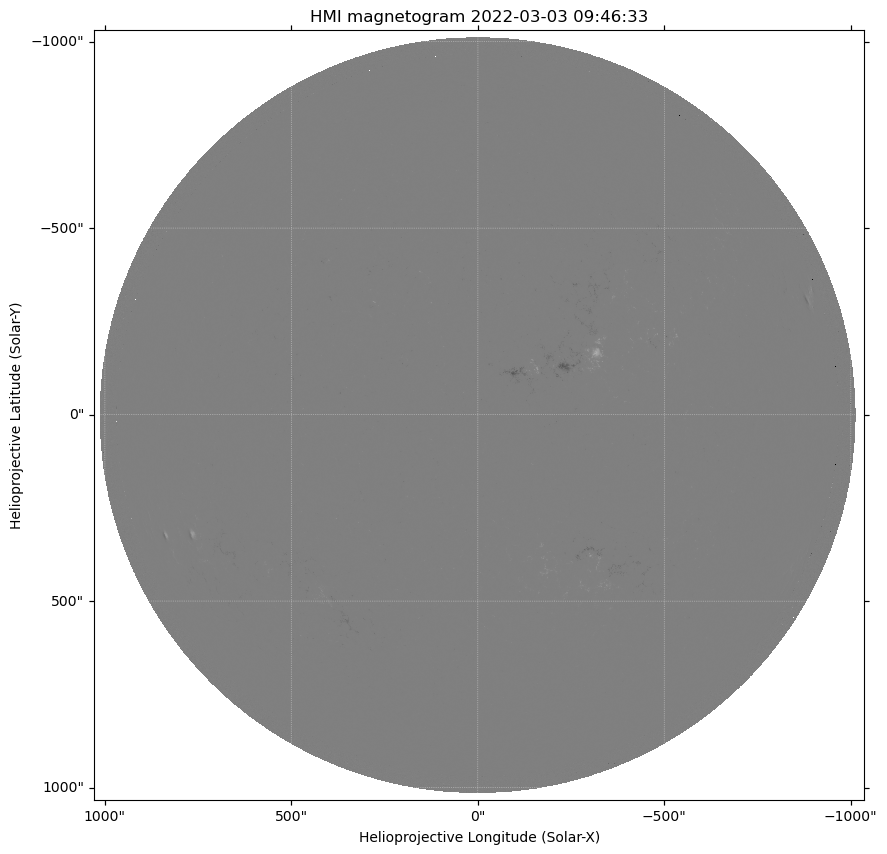

In [46]:
hmi_map = sunpy.map.Map(downloaded_files_hmi2)
plt.close()
fig = plt.figure(figsize=(12, 10))
ax_hmi = fig.add_subplot(111, projection=hmi_map)
hmi_map.plot(axes=ax_hmi)


In [47]:
downloaded_files_hmi

['/disk/plasma/xw2/PFSS/data/hmi.m_45s.2022.03.03_09_44_15_TAI.magnetogram.fits']

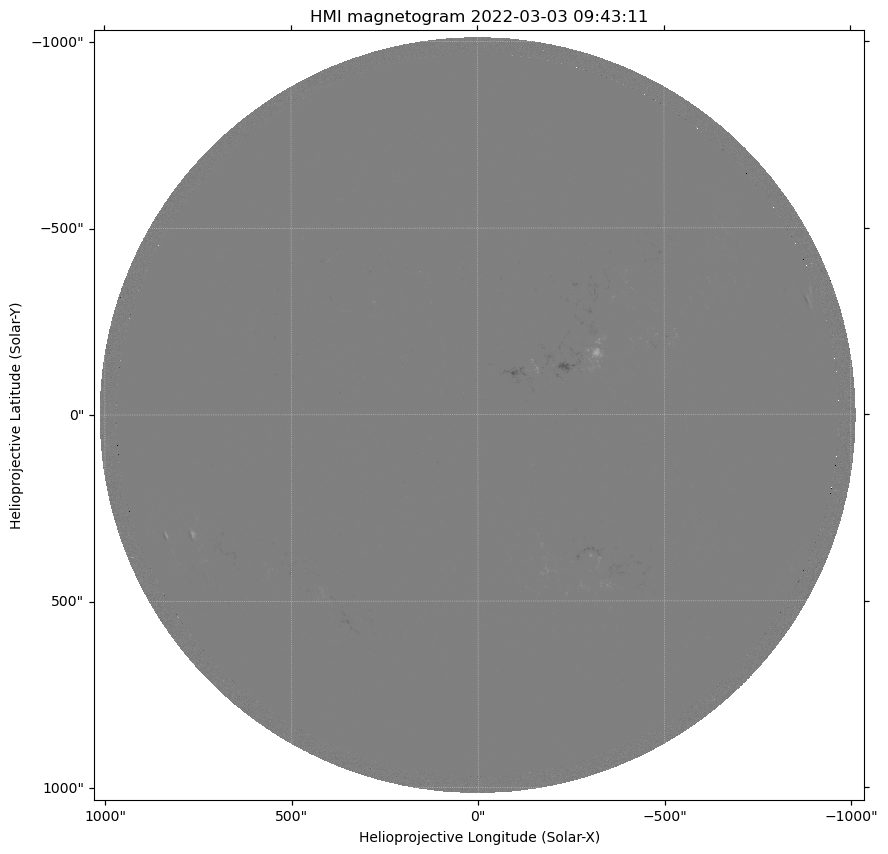

In [48]:
hmi_map = sunpy.map.Map(downloaded_files_hmi)
plt.close()
fig = plt.figure(figsize=(12, 10))
ax_hmi = fig.add_subplot(111, projection=hmi_map)
hmi_map.plot(axes=ax_hmi)


### AIA

In [ ]:
aia_map = sunpy.map.Map(downloaded_files_aia)

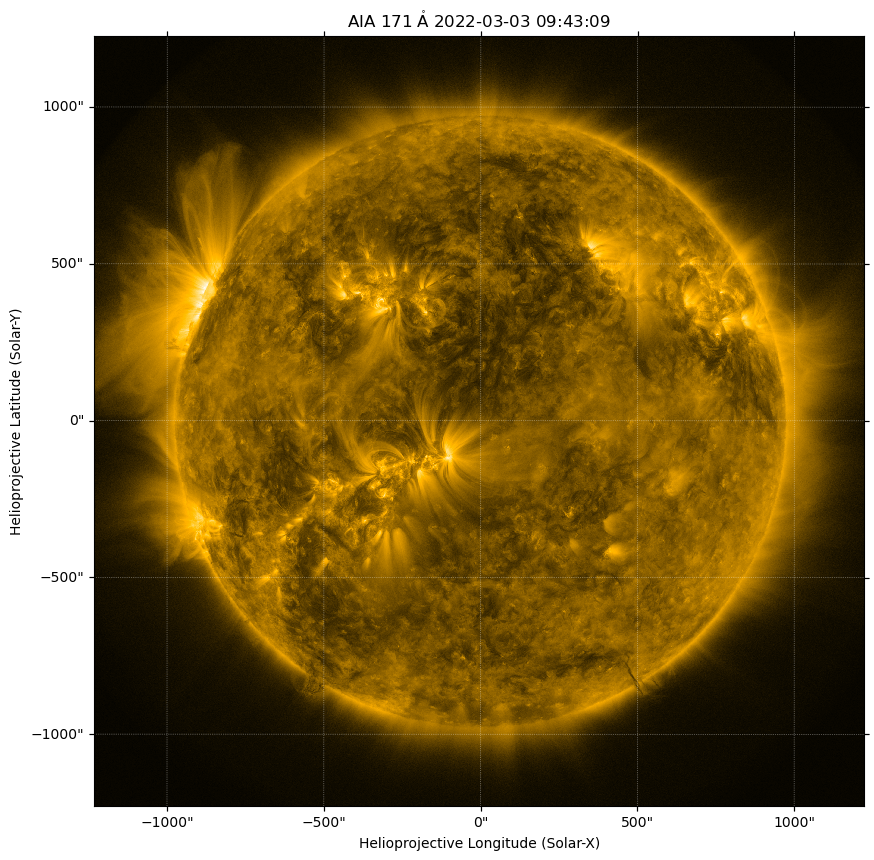

In [ ]:
plt.close()
fig = plt.figure(figsize=(12, 10))
ax_aia = fig.add_subplot(111, projection=aia_map)
aia_map.plot(axes=ax_aia)